In [1]:
import pandas as pd
data= pd.read_csv('../datasets/heusler_magnetic.csv')
print("Data shape:", data.shape)
print(data.head())

Data shape: (1153, 12)
  formula  heusler type  num_electron struct type  latt const  tetragonality  \
0  V2ScAl  Full Heusler            16        D022        5.49         1.5610   
1  V2ScGa  Full Heusler            16        D022        5.43         1.5893   
2  V2ScIn  Full Heusler            16        D022        5.66         1.5583   
3  V2ScSi  Full Heusler            17        D022        5.34         1.5993   
4  V2ScGe  Full Heusler            17        D022        5.39         1.6104   

   e_form  pol fermi gap width stability    mu_b  mu_b saturation  
0   0.046       0.10    No gap     False  0.0002             0.03  
1  -0.014      36.93    No gap      True  0.1775            25.88  
2   0.191      34.28    No gap     False  0.1624            21.32  
3  -0.122      19.59    No gap      True  0.6638           101.12  
4  -0.087      10.09    No gap      True  0.7492           110.21  


In [2]:
replace_value = 0

# Replace "no" and "no gap" with the replacement value
data['gap width'] = data['gap width'].replace(['No', 'No gap'], replace_value)

# Convert to numeric if needed (this will convert the string numbers to integers/floats)
data['gap width'] = pd.to_numeric(data['gap width'])
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1153 entries, 0 to 1152
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   formula          1153 non-null   str    
 1   heusler type     1153 non-null   str    
 2   num_electron     1153 non-null   int64  
 3   struct type      1153 non-null   str    
 4   latt const       1153 non-null   float64
 5   tetragonality    1153 non-null   float64
 6   e_form           1081 non-null   float64
 7   pol fermi        1081 non-null   float64
 8   gap width        1072 non-null   float64
 9   stability        1081 non-null   object 
 10  mu_b             1153 non-null   float64
 11  mu_b saturation  1081 non-null   float64
dtypes: float64(7), int64(1), object(1), str(3)
memory usage: 108.2+ KB


In [3]:
# Reset index to ensure row numbers are correct
data.reset_index(inplace=True)
#  Group by "heusler alloy type" and find min/max index
grouped = data.groupby("heusler type")["index"].agg(["min", "max"])

#  Convert to a more readable format
ranges = {
    alloy_type: (row["min"], row["max"])
    for alloy_type, row in grouped.iterrows()
}

print("Row number ranges for each Heusler alloy type:")
for alloy_type, (start, end) in ranges.items():
    print(f"{alloy_type}: {start} - {end}")

Row number ranges for each Heusler alloy type:
Full Heusler: 0 - 575
Half Heusler: 576 - 1024
Inverse Heusler: 1025 - 1152


In [4]:
# Define the segments using row indices
segment1_indices = range(0, 575)  
segment2_indices = range(576, 1025)
segment3_indices = range(1025, len(data))  

# Create a helper function to fill null values based on a segment's mean
def fill_by_segment_mean(column_name, data, segment_indices):
    # Calculate the mean for the segment 
    segment_mean = data.loc[segment_indices, column_name].mean()
    
    # Fill NaNs within the specified segment
    data.loc[segment_indices, column_name] = data.loc[segment_indices, column_name].fillna(segment_mean)

# Now apply this function to the desired columns for each segment
columns_to_fill = ['e_form', 'pol fermi', 'mu_b saturation','gap width']

for column in columns_to_fill:
    fill_by_segment_mean(column, data, segment1_indices)
    fill_by_segment_mean(column, data, segment2_indices)
    fill_by_segment_mean(column, data, segment3_indices)

filled_data = data.copy()  
filled_data.info() 

<class 'pandas.DataFrame'>
RangeIndex: 1153 entries, 0 to 1152
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   index            1153 non-null   int64  
 1   formula          1153 non-null   str    
 2   heusler type     1153 non-null   str    
 3   num_electron     1153 non-null   int64  
 4   struct type      1153 non-null   str    
 5   latt const       1153 non-null   float64
 6   tetragonality    1153 non-null   float64
 7   e_form           1153 non-null   float64
 8   pol fermi        1153 non-null   float64
 9   gap width        1153 non-null   float64
 10  stability        1081 non-null   object 
 11  mu_b             1153 non-null   float64
 12  mu_b saturation  1153 non-null   float64
dtypes: float64(7), int64(2), object(1), str(3)
memory usage: 117.2+ KB


In [5]:
# Renaming column name with other appropriate
filled_data.rename(columns={'heusler type': 'heusler_type','struct type': 'struct_type','latt const': 'latt_const',
                  'pol fermi':'pol_fermi','gap width':'gap_width', 'mu_b saturation':'mu_b_saturation'}, inplace=True)
filled_data

,index,formula,heusler_type,num_electron,struct_type,latt_const,tetragonality,e_form,pol_fermi,gap_width,stability,mu_b,mu_b_saturation
0,0,V2ScAl,Full Heusler,16,D022,5.4900,1.5610,0.046,0.10,0.000,False,0.0002,0.03
1,1,V2ScGa,Full Heusler,16,D022,5.4300,1.5893,-0.014,36.93,0.000,True,0.1775,25.88
2,2,V2ScIn,Full Heusler,16,D022,5.6600,1.5583,0.191,34.28,0.000,False,0.1624,21.32
3,3,V2ScSi,Full Heusler,17,D022,5.3400,1.5993,-0.122,19.59,0.000,True,0.6638,101.12
4,4,V2ScGe,Full Heusler,17,D022,5.3900,1.6104,-0.087,10.09,0.000,True,0.7492,110.21
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1148,1148,Fe2CoSb,Inverse Heusler,30,Xa,5.9920,1.0010,0.021,37.50,0.048,False,5.9328,1021.94
1149,1149,Fe2NiAl,Inverse Heusler,29,Xa,5.7455,0.9972,-0.292,10.33,0.228,True,4.7777,937.04
1150,1150,Fe2NiGa,Inverse Heusler,29,Xa,5.7570,1.0000,-0.183,6.86,0.304,True,4.8692,946.66
1151,1151,Fe2NiIn,Inverse Heusler,29,Xa,6.0193,1.0030,0.076,23.84,0.294,False,5.1485,873.12


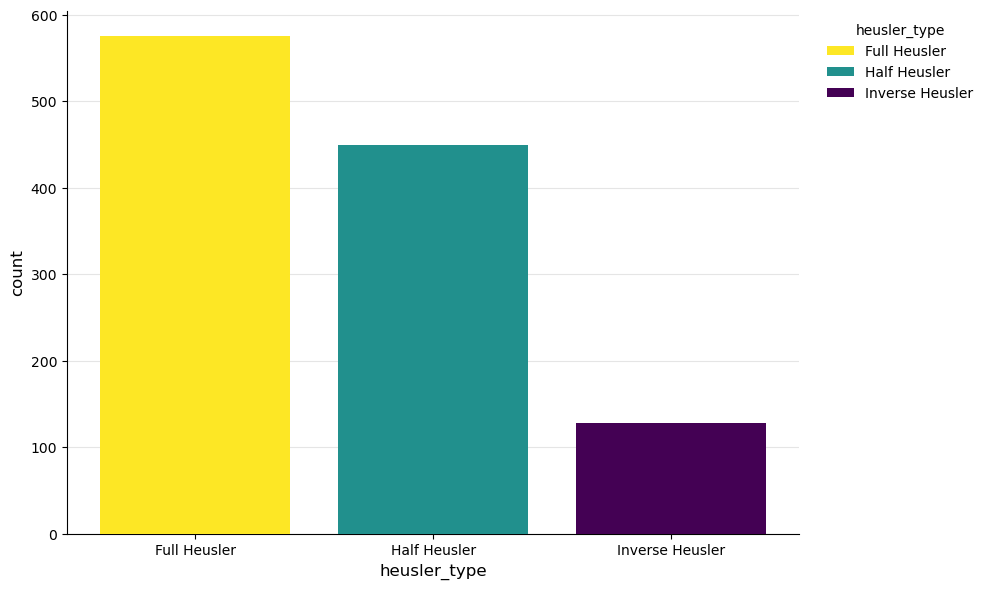

In [6]:
#understanding the data 
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
# color=px.colors.sequential.Viridis_r
# fig=px.histogram(filled_data, x='heusler_type', color='heusler_type', color_discrete_sequence = color)
# fig.show()
# 1. Prepare the data (Mimic Plotly's auto-aggregation)
counts = filled_data['heusler_type'].value_counts()
categories = counts.index
values = counts.values

# 2. Setup the Color Map (FIXED)
# Use mpl.colormaps['name'] instead of cm.get_cmap('name')
cmap = mpl.colormaps['viridis_r']
color_values = np.linspace(0, 1, len(categories))
colors = [cmap(val) for val in color_values]

# 3. Create the Plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the bars
bars = ax.bar(categories, values, color=colors, zorder=3)

# 4. Styling (Mimic Plotly's defaults)
ax.set_xlabel('heusler_type', fontsize=12)
ax.set_ylabel('count', fontsize=12)
ax.yaxis.grid(True, color='#E5E5E5', linestyle='-', zorder=0)

# Legend
ax.legend(bars, categories, title='heusler_type', 
          bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

# Clean up spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

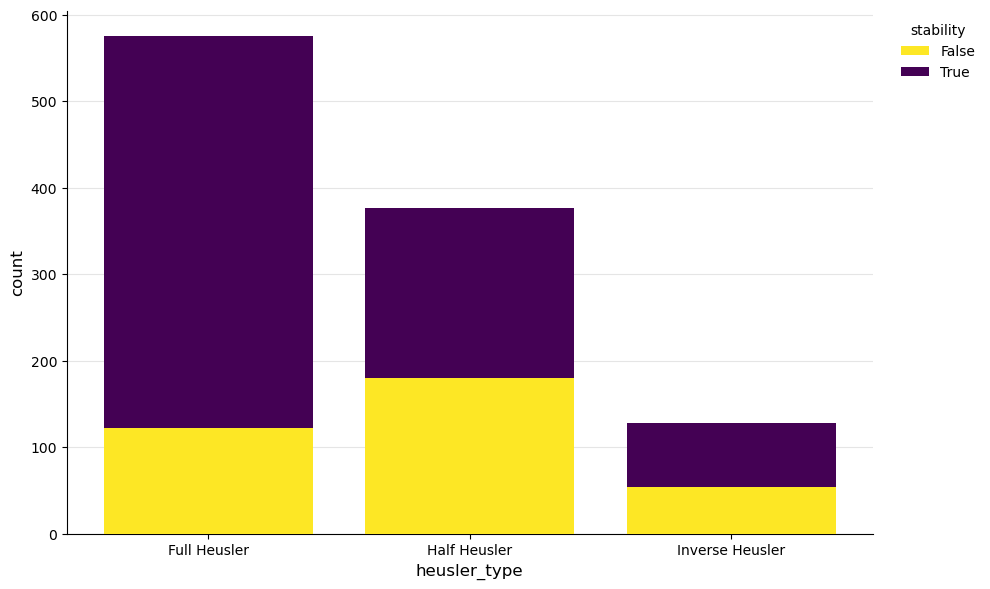

In [7]:
# 1. Prepare the data (Crosstab needed for stacking)
# We count frequency of 'stability' (columns) for each 'heusler_type' (rows)
plot_data = pd.crosstab(filled_data['heusler_type'], filled_data['stability'])

# 2. Setup the Color Map
# Generate colors based on the number of unique 'stability' categories
num_categories = len(plot_data.columns)
cmap = mpl.colormaps['viridis_r']
colors = [cmap(i) for i in np.linspace(0, 1, num_categories)]

# 3. Create the Plot
fig, ax = plt.subplots(figsize=(10, 6))

# Loop through columns to create stacked bars
bottom = np.zeros(len(plot_data))

for i, col_name in enumerate(plot_data.columns):
    ax.bar(plot_data.index, plot_data[col_name], 
           bottom=bottom,          # Stack on top of the previous layer
           color=colors[i], 
           label=col_name, 
           zorder=3)
    bottom += plot_data[col_name].values # Update the bottom for the next layer

# 4. Styling (Mimic Plotly defaults)
ax.set_xlabel('heusler_type', fontsize=12)
ax.set_ylabel('count', fontsize=12)
ax.yaxis.grid(True, color='#E5E5E5', linestyle='-', zorder=0)

# Legend (Title should be 'stability')
ax.legend(title='stability', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

# Clean up spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

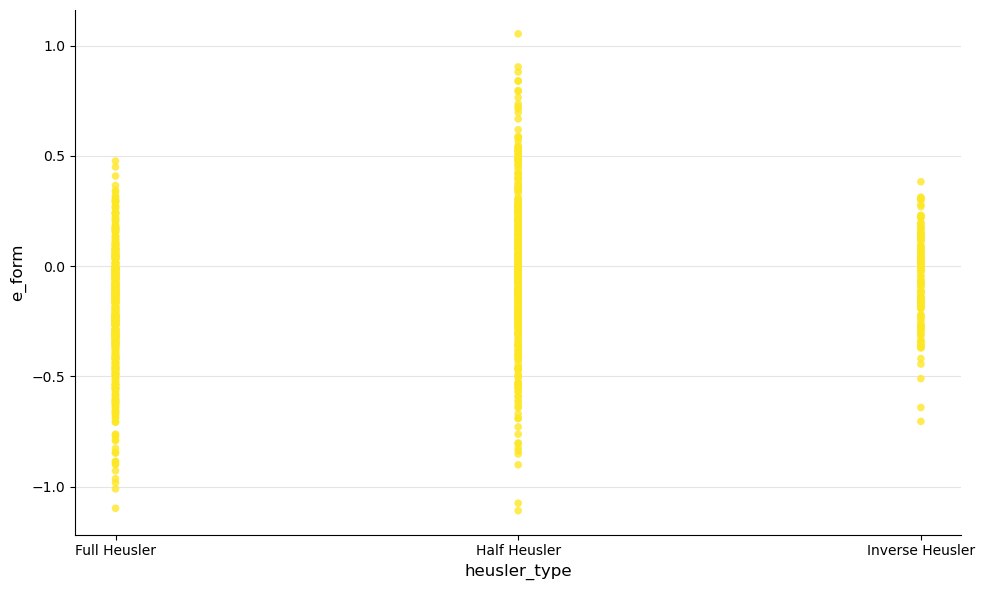

In [8]:
# 1. Setup the Color
# Since no column was mapped to color, we pick the first color of Viridis_r
# (Viridis_r typically starts with a yellowish color)
cmap = mpl.colormaps['viridis_r']
single_color = cmap(0) 

# 2. Create the Plot
fig, ax = plt.subplots(figsize=(10, 6))

# 3. Plot Scatter
# Plotly scatter defaults: no point borders, circle marker
ax.scatter(filled_data['heusler_type'], filled_data['e_form'], 
           color=single_color, 
           s=30,               # Adjust size to match Plotly default
           alpha=0.8,          # Slight transparency often looks better
           edgecolors='none',  # Plotly points don't have black outlines by default
           zorder=3)

# 4. Styling (Mimic Plotly defaults)
ax.set_xlabel('heusler_type', fontsize=12)
ax.set_ylabel('e_form', fontsize=12)
ax.yaxis.grid(True, color='#E5E5E5', linestyle='-', zorder=0)

# Clean up spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [9]:
# encoding
from sklearn.preprocessing import LabelEncoder
categorical_columns = ['formula','heusler_type', 'struct_type', 'stability']

# Initialize LabelEncoder
label_encoder = LabelEncoder()
# Apply label encoding to each ordinal categorical column
for col in categorical_columns:
    filled_data[col] = label_encoder.fit_transform(filled_data[col])
    
print(filled_data)

      index  formula  heusler_type  num_electron  struct_type  latt_const  \
0         0      971             0            16            1      5.4900   
1         1      973             0            16            1      5.4300   
2         2      975             0            16            1      5.6600   
3         3      978             0            17            1      5.3400   
4         4      974             0            17            1      5.3900   
...     ...      ...           ...           ...          ...         ...   
1148   1148      277             2            30            4      5.9920   
1149   1149      309             2            29            4      5.7455   
1150   1150      311             2            29            4      5.7570   
1151   1151      313             2            29            4      6.0193   
1152   1152       38             2            31            4      5.6900   

      tetragonality  e_form  pol_fermi  gap_width  stability    mu_b  \
0  

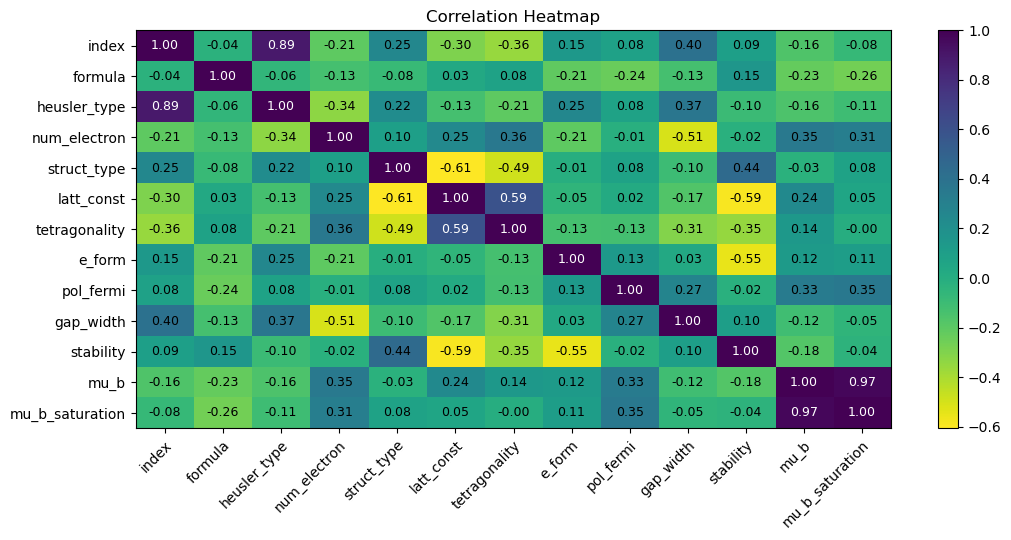

In [10]:
# 1. Calculate the correlation matrix
correlation_matrix = filled_data.corr()

# 2. Setup the figure
fig, ax = plt.subplots(figsize=(11, 5.5))

# 3. Create the Heatmap (Image)
# 'viridis_r' maps low values to bright yellow and high values to dark purple
im = ax.imshow(correlation_matrix, cmap='viridis_r', aspect='auto')

# 4. Add Colorbar
cbar = ax.figure.colorbar(im, ax=ax)

# 5. Configure Ticks and Labels
# Set ticks at the center of each cell
ax.set_xticks(np.arange(len(correlation_matrix.columns)))
ax.set_yticks(np.arange(len(correlation_matrix.index)))

# Label ticks with column/index names
ax.set_xticklabels(correlation_matrix.columns)
ax.set_yticklabels(correlation_matrix.index)

# Rotate x-axis labels for readability (standard in Seaborn)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# 6. Add Annotations (The 'annot=True' part)
# Loop over data dimensions and create text annotations.
for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        val = correlation_matrix.iloc[i, j]
        
        # Determine text color for contrast 
        # (viridis_r: low values are yellow/bright -> black text, high values are purple/dark -> white text)
        # We use a threshold (e.g., midpoint of the data range) or simple logic based on the map.
        # Since viridis_r gets darker as value increases, we use white for high values.
        text_color = "white" if val > 0.5 else "black" 
        
        text = ax.text(j, i, f"{val:.2f}",
                       ha="center", va="center", color=text_color, fontsize=9)

# 7. Final Polish
ax.set_title("Correlation Heatmap")
fig.tight_layout()
plt.show()

In [11]:
#dropping the Mu_b since mu_b and mu_b saturtion has high correlation and index is just a number.
df=filled_data.drop(['mu_b','index' ], axis = 1)
print(df.head(5))

   formula  heusler_type  num_electron  struct_type  latt_const  \
0      971             0            16            1        5.49   
1      973             0            16            1        5.43   
2      975             0            16            1        5.66   
3      978             0            17            1        5.34   
4      974             0            17            1        5.39   

   tetragonality  e_form  pol_fermi  gap_width  stability  mu_b_saturation  
0         1.5610   0.046       0.10        0.0          0             0.03  
1         1.5893  -0.014      36.93        0.0          1            25.88  
2         1.5583   0.191      34.28        0.0          0            21.32  
3         1.5993  -0.122      19.59        0.0          1           101.12  
4         1.6104  -0.087      10.09        0.0          1           110.21  


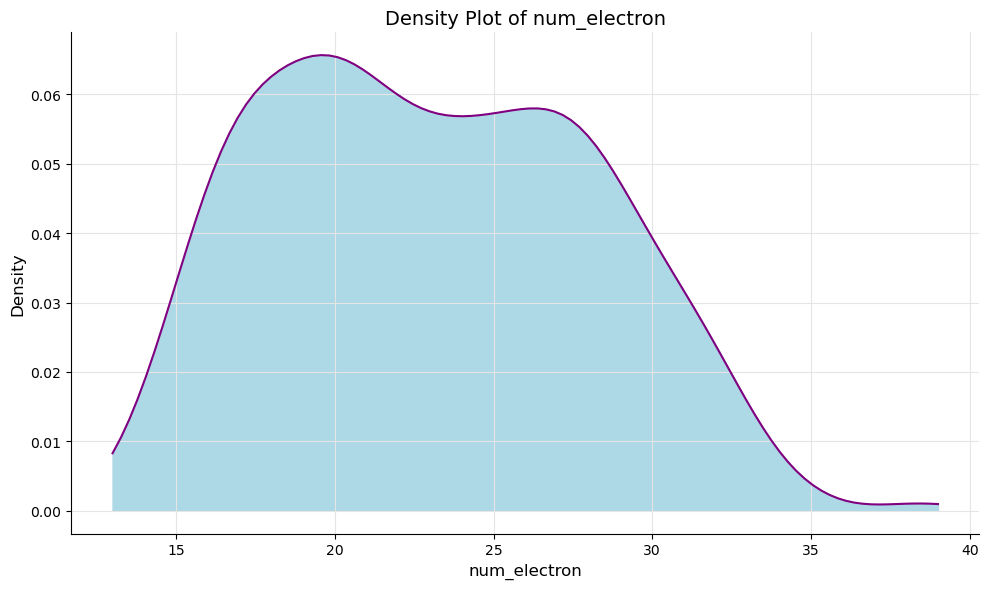

In [12]:
from scipy.stats import gaussian_kde

# 1. Calculation (Same as your original code)
kde = gaussian_kde(df['num_electron'])

# Define the x-axis range
x = np.linspace(min(df['num_electron']), max(filled_data['num_electron']), 100)
# Calculate the corresponding density values
y = kde(x)

# 2. Create the Plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the line (line_color='purple')
ax.plot(x, y, color='purple', zorder=2)

# Fill the area under the curve (fill='tozeroy', fillcolor='lightblue')
ax.fill_between(x, y, color='lightblue', alpha=1.0, zorder=1)

# 3. Styling (Mimic Plotly labels and title)
ax.set_xlabel('num_electron', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Density Plot of num_electron', fontsize=14)

# Grid styling (Plotly usually has a light grid)
ax.grid(True, color='#E5E5E5', linestyle='-', zorder=0)

# Remove top and right spines for a cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

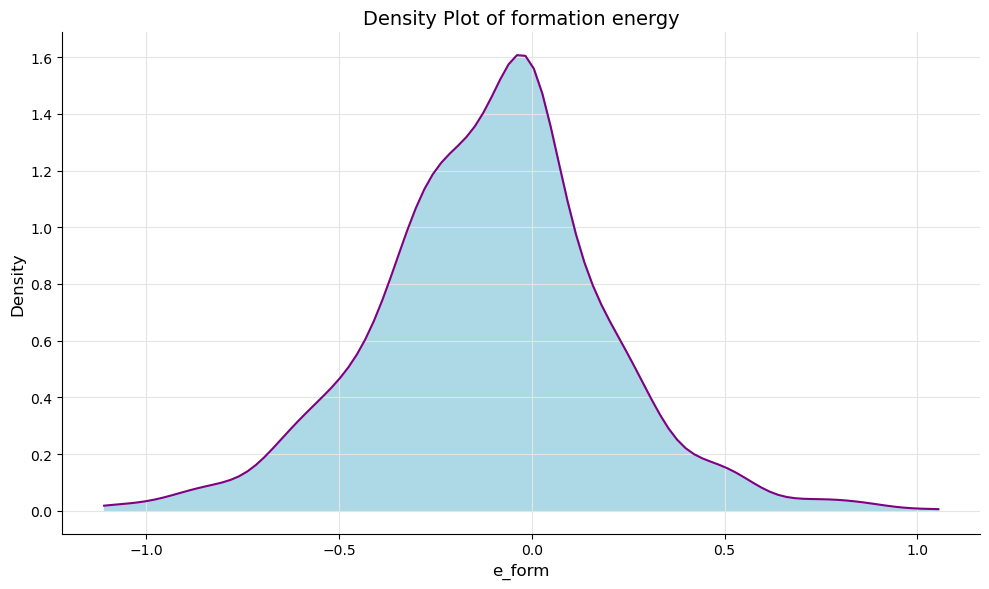

In [13]:
# 1. Calculation (Same as your code)
kde_for = gaussian_kde(df['e_form'])

# Define the x-axis range for plotting the KDE
x_f = np.linspace(min(df['e_form']), max(filled_data['e_form']), 100)
# Calculate the corresponding density values for the KDE
y = kde_for(x_f)

# 2. Create the Plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the line (line_color='purple')
ax.plot(x_f, y, color='purple', zorder=2)

# Fill the area under the curve (fill='tozeroy', fillcolor='lightblue')
ax.fill_between(x_f, y, color='lightblue', alpha=1.0, zorder=1)

# 3. Styling (Mimic Plotly labels and title)
ax.set_xlabel('e_form', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Density Plot of formation energy', fontsize=14)

# Grid styling
ax.grid(True, color='#E5E5E5', linestyle='-', zorder=0)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [14]:
X=df.drop(['heusler_type','formula'], axis=1)
y=df['heusler_type']

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,random_state=1)

In [16]:
from sklearn.preprocessing import StandardScaler
scaler_d = StandardScaler()
X_train_scaled = scaler_d.fit_transform(X_train)
X_test_scaled = scaler_d.transform(X_test)

In [17]:
from sklearn.linear_model import LogisticRegression

# Create the logistic regression model with multinomial option
lr_d = LogisticRegression(solver='lbfgs')

# Fit the model
lr_d.fit(X_train_scaled, y_train)

# Predict on the test set
lr_pred_d = lr_d.predict(X_test_scaled)

In [18]:
# Importing necessary libraries
from sklearn.tree import DecisionTreeClassifier

# Initialize the DecisionTreeClassifier
clf = DecisionTreeClassifier()

# Train the DecisionTreeClassifier
clf.fit(X_train_scaled, y_train)

# Make predictions on the testing set
dec_pred = clf.predict(X_test_scaled)

In [19]:
# Importing necessary library
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
# Initialize the RandomForestClassifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the RandomForestClassifier
rf_clf.fit(X_train_scaled, y_train)

# Make predictions on the testing set
y_pred_rf = rf_clf.predict(X_test_scaled)

# Calculate accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Classifier Accuracy:", accuracy_rf)

Random Forest Classifier Accuracy: 0.9971098265895953


In [20]:
# Importing necessary library
from sklearn.naive_bayes import GaussianNB

# Initialize the Gaussian Naive Bayes Classifier
nb_clf = GaussianNB()

# Train the Gaussian Naive Bayes Classifier
nb_clf.fit(X_train_scaled, y_train)

# Make predictions on the testing set
y_pred_nb = nb_clf.predict(X_test_scaled)

# Calculate accuracy
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print("Gaussian Naive Bayes Classifier Accuracy:", accuracy_nb)

Gaussian Naive Bayes Classifier Accuracy: 0.9739884393063584


In [21]:
lr_d_report = classification_report(y_test, lr_pred_d)
dec_report = classification_report(y_test, dec_pred)
print("="*20, "Logistic regression report:", "="*20, '\n')
print(lr_d_report)
print("="*20, "Decision tree classifier report:", "="*20, '\n')
print(dec_report)

==================== Logistic regression report: ==================== 

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       176
           1       0.99      0.98      0.98       138
           2       0.89      1.00      0.94        32

    accuracy                           0.98       346
   macro avg       0.96      0.99      0.97       346
weighted avg       0.98      0.98      0.98       346

==================== Decision tree classifier report: ==================== 

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       176
           1       1.00      1.00      1.00       138
           2       1.00      1.00      1.00        32

    accuracy                           1.00       346
   macro avg       1.00      1.00      1.00       346
weighted avg       1.00      1.00      1.00       346



In [22]:
rf_report = classification_report(y_test, y_pred_rf)
nb_report = classification_report(y_test, y_pred_nb)
print("="*20, "Random forest classifier report:", "="*20, '\n')
print(rf_report)
print("="*20, "Naive bayes classifier report:", "="*20, '\n')
print(nb_report)

==================== Random forest classifier report: ==================== 

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       176
           1       1.00      0.99      1.00       138
           2       0.97      1.00      0.98        32

    accuracy                           1.00       346
   macro avg       0.99      1.00      0.99       346
weighted avg       1.00      1.00      1.00       346

==================== Naive bayes classifier report: ==================== 

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       176
           1       0.96      0.97      0.97       138
           2       1.00      0.97      0.98        32

    accuracy                           0.97       346
   macro avg       0.98      0.97      0.98       346
weighted avg       0.97      0.97      0.97       346



In [23]:
X_d=df.drop(['heusler_type','formula'], axis=1)
y_d=df['heusler_type']

In [24]:
from sklearn.model_selection import train_test_split
# Splitting the data into training and testing sets for diabetes balanced

X_dtrain, X_dtest, y_dtrain, y_dtest = train_test_split(X_d, y_d, test_size=0.4,random_state=2)

In [25]:
clff = DecisionTreeClassifier(
    criterion='gini',  
    max_depth=2,       
    min_samples_split=2,  
    min_samples_leaf=1,   
    random_state=2      
)

# Train the DecisionTreeClassifier
clff.fit(X_dtrain.values, y_dtrain.values)

# Make predictions on the testing set
dec_predd = clff.predict(X_dtest.values)

In [26]:
dec_dreport = classification_report(y_dtest, dec_predd)
print("="*20, "Advanced Decision tree classifier report:", "="*20, '\n')
print(dec_dreport)

==================== Advanced Decision tree classifier report: ==================== 

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       232
           1       1.00      0.82      0.90       175
           2       0.64      1.00      0.78        55

    accuracy                           0.93       462
   macro avg       0.88      0.94      0.89       462
weighted avg       0.96      0.93      0.94       462



In [27]:
from sklearn.model_selection import cross_val_score

clff = DecisionTreeClassifier(
    criterion='gini',        
    max_depth=2,             
    min_samples_split=2,      
    min_samples_leaf=1,       
    random_state=2            
)

# Perform k-fold cross-validation
k = 5  
cv_scores = cross_val_score(clff, X_dtrain, y_dtrain, cv=k)

# Print the cross-validation scores
print("Cross-validation scores:", cv_scores)

# Print the mean and standard deviation of the cross-validation scores
print("Mean CV accuracy:", cv_scores.mean())
print("Standard deviation of CV accuracy:", cv_scores.std())

Cross-validation scores: [0.9352518  0.9057971  0.93478261 0.93478261 0.94927536]
Mean CV accuracy: 0.9319778959441143
Standard deviation of CV accuracy: 0.014220320734420111


In [28]:
print(X_dtest)

      num_electron  struct_type  latt_const  tetragonality   e_form  \
232             25            2      5.8000         1.0000 -0.35400   
702             17            0      5.4900         1.0000  0.24200   
992             16            6      0.0734         0.2917 -0.00678   
843             24            0      5.4600         1.0000  0.34900   
212             28            1      5.4657         1.4094 -0.01100   
...            ...          ...         ...            ...      ...   
157             22            2      5.8700         1.0000 -0.35100   
737             15            0      5.9400         1.0000 -0.27500   
1010            17            6     -0.5685        -0.0948 -0.00678   
333             27            2      5.9800         1.0000 -0.30500   
979             16            6     -0.0456         0.1406 -0.00678   

       pol_fermi  gap_width  stability  mu_b_saturation  
232   100.000000   0.365000          1       190.130000  
702    44.830000   0.000000    

In [29]:
print(y_dtest)

232     0
702     1
992     1
843     1
212     0
       ..
157     0
737     1
1010    1
333     0
979     1
Name: heusler_type, Length: 462, dtype: int64
